# Strategy Evaluation & Backtesting

## Objective 
The objective of this notebook is to evaluate whether the market regime forecasts generated in the previous notebook can be used to construct a simple, systematic investment strategy. Rather than assessing forecasting accuracy alone, this notebook focuses on determining whether the predicted market regimes provide actionable information capable of improving investment performance.

To accomplish this, trading rules will be defined according to the forecasted market regimes, and the resulting strategy will be evaluated through historical backtesting. The strategy's cumulative returns and risk characteristics will then be compared with those of a traditional buy-and-hold benchmark to assess the practical value of the forecasting system.

## Roadmap
1. Environment Setup
2. Trading Strategy Design 
3. Generat Trading Signals
4. Portfolio Backtesting 
5. Strategy Performance Evaluation
6. Strategy Visualization
7. Final Strategy Assessment

----

## Environment Setup

Before evaluating the forecasting strategy, the required libraries, project configuration, and forecasting datasets are loaded. Establishing a consistent computational environment ensures that all subsequent analyses are reproducible and that the trading strategy is evaluated using the same forecasting pipeline developed throughout the previous notebooks.

In this notebook, the forecasting results generated in Notebook 7 will serve as the foundation for constructing and evaluating a systematic investment strategy. The environment setup therefore focuses on loading both the forecasting outputs and the historical market data required for backtesting.

In [1]:
# ============================================
# Import Libraries and Load Configuration
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap

import numpy as np
import seaborn as sns

import os
import sys

# Machine Learning
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Absolute Path To The Project Root
project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

from config import *

In [2]:
# ============================================
# Asset Name
# ============================================

if len(ASSETS) != 1:
    raise ValueError(
        "This notebook is designed for single-asset analysis."
    )

asset_name = (
    ASSETS[0]
    .lower()
    .replace("-", "_")
)

In [3]:
# ============================================
# Load Datasets
# ============================================

# Engineered features
raw_path = os.path.join(
    RAW_DATA_PATH,
    f"{asset_name}_{INTERVAL}_raw.csv"
)

raw_df = pd.read_csv(
    raw_path,
    parse_dates=["Date"],
    index_col = "Date"
)

# Market regime dataset
market_regime_path = os.path.join(
    PROCESSED_DATA_PATH,
    f"{asset_name}_market_regime.csv"
)

market_regime_df = pd.read_csv(
    market_regime_path,
    parse_dates=["Date"],
    index_col = "Date"
)

print("=" * 60)
print("Datasets Successfully Loaded")
print("=" * 60)

print(f"Historical Market Data : {raw_df.shape}")
print(f"Market Regime Dataset  : {market_regime_df.shape}")

Datasets Successfully Loaded
Historical Market Data : (3095, 5)
Market Regime Dataset  : (3065, 5)


----

## Trading Strategy Design

Before evaluating the forecasting model in a realistic investment scenario, the predicted market regimes must be translated into systematic trading decisions. A forecasting model by itself only provides expectations about future market conditions; however, an investment strategy requires explicit rules that determine when to enter, maintain, or exit a position.

In this section, a rule-based trading strategy is designed by associating each predicted market regime with a specific trading action. These rules provide the decision-making framework that will later be evaluated through historical backtesting and compared against a passive buy-and-hold benchmark.

> ### Trading Rules Definition

Before a forecasting model can be evaluated as an investment strategy, its predictions must be converted into actionable trading decisions. Since the forecasting model predicts market regimes rather than explicit buy or sell signals, a deterministic set of trading rules is required to translate each predicted regime into a corresponding portfolio action.

The trading rules defined in this subsection establish the investment policy that will be followed throughout the backtesting process. These rules remain fixed during the evaluation, ensuring that the strategy is systematic, transparent, and fully reproducible.

In [4]:
# ============================================
# Trading Rules
# ============================================

trading_rules = pd.DataFrame(
    {
        "Predicted Market Regime": [
            "Moderate-Volatility Bullish",
            "Low-Volatility Neutral",
            "High-Volatility Transition",
            "High-Volatility Bearish"
        ],

        "Trading Action": [
            "Buy",
            "Hold",
            "Reduce Exposure",
            "Sell"
        ],

        "Portfolio Position": [
            "100% Invested",
            "Maintain Current Position",
            "50% Invested",
            "100% Cash"
        ],

        "Investment Rationale": [
            "Positive market outlook with controlled volatility.",
            "Stable market conditions with no strong directional signal.",
            "Higher uncertainty suggests a defensive allocation.",
            "Expected downside risk favors capital preservation."
        ]
    }
)

print("=" * 70)
print("Trading Rules")
print("=" * 70)

display(trading_rules)

Trading Rules


,Predicted Market Regime,Trading Action,Portfolio Position,Investment Rationale
0,Moderate-Volatility Bullish,Buy,100% Invested,Positive market outlook with controlled volati...
1,Low-Volatility Neutral,Hold,Maintain Current Position,Stable market conditions with no strong direct...
2,High-Volatility Transition,Reduce Exposure,50% Invested,Higher uncertainty suggests a defensive alloca...
3,High-Volatility Bearish,Sell,100% Cash,Expected downside risk favors capital preserva...


The trading rules presented above define the investment policy that will be applied consistently throughout the backtesting process. By establishing a fixed relationship between each predicted market regime and its corresponding portfolio action, the evaluation remains systematic and reproducible. The next subsection implements these rules by converting the predicted market regimes into executable trading signals.

> ### Trading Signal Generation

Once the trading rules have been established, they must be translated into executable trading signals that can be applied throughout the historical dataset.

In this subsection, each predicted market regime is converted into a numerical trading position according to the predefined investment policy. These positions represent the portfolio allocation that will be assumed at each point in time and serve as the foundation for the backtesting process performed in the following section.

In [5]:
# ============================================
# Generate Trading Signals
# ============================================

# Map each predicted market regime to a portfolio position
position_mapping = {
    "Moderate-Volatility Bullish": 1.0,   # Fully invested
    "Low-Volatility Neutral": 1.0,        # Maintain investment
    "High-Volatility Transition": 0.5,    # Reduce exposure
    "High-Volatility Bearish": 0.0        # Exit to cash
}

# Generate trading positions
market_regime_df["Position"] = (
    market_regime_df["Market_Regime"]
    .map(position_mapping)
)

# Display a sample of the generated trading signals
market_regime_df[
    ["Market_Regime", "Position"]
].head(10)

,Market_Regime,Position
Date,,
2018-01-31,High-Volatility Transition,0.5
2018-02-01,High-Volatility Bearish,0.0
2018-02-02,High-Volatility Bearish,0.0
2018-02-03,High-Volatility Transition,0.5
2018-02-04,High-Volatility Bearish,0.0
2018-02-05,High-Volatility Bearish,0.0
2018-02-06,High-Volatility Transition,0.5
2018-02-07,High-Volatility Transition,0.5
2018-02-08,High-Volatility Transition,0.5


The predicted market regimes have now been transformed into numerical portfolio positions that represent the investment allocation at each point in time. These positions constitute the trading signals that will be used throughout the remainder of the notebook to simulate portfolio performance under the proposed investment strategy. With the trading signals established, the next step is to evaluate how this strategy would have performed through historical backtesting.

-----

## Strategy Backtesting

Once the trading signals have been generated, the proposed investment strategy can be evaluated through historical backtesting. Backtesting consists of simulating how the strategy would have performed if the generated trading decisions had been followed throughout the available historical market data.

This section combines the portfolio positions derived from the predicted market regimes with the historical market returns to calculate the performance of the proposed strategy. The resulting portfolio evolution will then be compared with a passive buy-and-hold benchmark in order to assess whether the forecasting model provides practical value for investment decision-making.

> ### Strategy Return Calculation

The first step in evaluating the proposed trading strategy is to calculate the returns generated by following the portfolio positions defined in the previous section. Since the strategy adjusts its market exposure according to the predicted market regime, the daily portfolio return depends on both the observed market return and the investment position held during that period.

In this subsection, the historical market returns are combined with the generated trading positions to compute the daily returns of the forecasting-based investment strategy. These strategy returns provide the foundation for constructing the portfolio performance and comparing it against a passive buy-and-hold investment approach.

In [6]:
# ============================================
# Merge Historical Prices with Trading Positions
# ============================================

# Merge the historical price data with the generated trading positions
backtest_df = raw_df.join(
    market_regime_df[["Market_Regime", "Position"]],
    how="inner"
)

print("=" * 60)
print("Backtesting Dataset")
print("=" * 60)

display(backtest_df.head())

Backtesting Dataset


,Close,High,Low,Open,Volume,Market_Regime,Position
Date,,,,,,,
2018-01-31,10221.099609,10381.599609,9777.419922,10108.200195,8041160192,High-Volatility Transition,0.5
2018-02-01,9170.540039,10288.799805,8812.280273,10237.299805,9959400448,High-Volatility Bearish,0.0
2018-02-02,8830.750000,9142.280273,7796.490234,9142.280273,12726899712,High-Volatility Bearish,0.0
2018-02-03,9174.910156,9430.750000,8251.629883,8852.120117,7263790080,High-Volatility Transition,0.5
2018-02-04,8277.009766,9334.870117,8031.220215,9175.700195,7073549824,High-Volatility Bearish,0.0


The historical market data and the generated portfolio positions have now been combined into a unified backtesting dataset. This integrated dataset contains all the information required to evaluate the proposed investment strategy. The next step consists of calculating both the daily market returns and the corresponding strategy returns based on the portfolio positions generated by the forecasting model.

In [7]:
# ============================================
# Calculate Strategy Returns
# ============================================

# Calculate daily market returns
backtest_df["Market_Return"] = backtest_df["Close"].pct_change()

# Calculate strategy returns based on portfolio exposure
backtest_df["Strategy_Return"] = (backtest_df["Market_Return"] * backtest_df["Position"])

# Remove the first observation generated by pct_change()
backtest_df = backtest_df.dropna()

print("=" * 60)
print("Strategy Returns")
print("=" * 60)

display(
    backtest_df[
        [
            "Close",
            "Market_Regime",
            "Position",
            "Market_Return",
            "Strategy_Return"
        ]
    ].head(10)
)

Strategy Returns


,Close,Market_Regime,Position,Market_Return,Strategy_Return
Date,,,,,
2018-02-01,9170.540039,High-Volatility Bearish,0.0,-0.102783,-0.000000
2018-02-02,8830.750000,High-Volatility Bearish,0.0,-0.037052,-0.000000
2018-02-03,9174.910156,High-Volatility Transition,0.5,0.038973,0.019486
2018-02-04,8277.009766,High-Volatility Bearish,0.0,-0.097865,-0.000000
2018-02-05,6955.270020,High-Volatility Bearish,0.0,-0.159688,-0.000000
2018-02-06,7754.000000,High-Volatility Transition,0.5,0.114838,0.057419
2018-02-07,7621.299805,High-Volatility Transition,0.5,-0.017114,-0.008557
2018-02-08,8265.589844,High-Volatility Transition,0.5,0.084538,0.042269
2018-02-09,8736.980469,High-Volatility Transition,0.5,0.057030,0.028515


Before evaluating the cumulative performance of the proposed trading strategy, the generated portfolio positions must be aligned with the information that would have been available in a real trading environment. Since a market regime can only be identified after the current trading period has been observed, any investment decision based on that prediction can only be executed during the following trading period. Therefore, the portfolio positions are shifted forward by one observation to ensure that the backtesting procedure remains free from look-ahead bias and accurately reflects realistic trading conditions.

In [8]:
# ============================================
# Adjust Trading Positions
# ============================================

# Shift positions forward by one trading period to avoid look-ahead bias
backtest_df["Position"] = backtest_df["Position"].shift(1)

# Remove the first observation generated by the shift
backtest_df = backtest_df.dropna()

print("=" * 60)
print("Adjusted Trading Positions")
print("=" * 60)

display(
    backtest_df[
        [
            "Market_Regime",
            "Position",
            "Market_Return",
            "Strategy_Return"
        ]
    ].head(10)
)

Adjusted Trading Positions


,Market_Regime,Position,Market_Return,Strategy_Return
Date,,,,
2018-02-02,High-Volatility Bearish,0.0,-0.037052,-0.000000
2018-02-03,High-Volatility Transition,0.0,0.038973,0.019486
2018-02-04,High-Volatility Bearish,0.5,-0.097865,-0.000000
2018-02-05,High-Volatility Bearish,0.0,-0.159688,-0.000000
2018-02-06,High-Volatility Transition,0.0,0.114838,0.057419
2018-02-07,High-Volatility Transition,0.5,-0.017114,-0.008557
2018-02-08,High-Volatility Transition,0.5,0.084538,0.042269
2018-02-09,High-Volatility Transition,0.5,0.057030,0.028515
2018-02-10,High-Volatility Transition,0.5,-0.013172,-0.006586


In [9]:
# ============================================
# Recalculate Strategy Returns
# ============================================

backtest_df["Strategy_Return"] = (
    backtest_df["Market_Return"] * backtest_df["Position"]
)

display(
    backtest_df[
        [
            "Market_Regime",
            "Position",
            "Market_Return",
            "Strategy_Return"
        ]
    ].head(10)
)

,Market_Regime,Position,Market_Return,Strategy_Return
Date,,,,
2018-02-02,High-Volatility Bearish,0.0,-0.037052,-0.000000
2018-02-03,High-Volatility Transition,0.0,0.038973,0.000000
2018-02-04,High-Volatility Bearish,0.5,-0.097865,-0.048932
2018-02-05,High-Volatility Bearish,0.0,-0.159688,-0.000000
2018-02-06,High-Volatility Transition,0.0,0.114838,0.000000
2018-02-07,High-Volatility Transition,0.5,-0.017114,-0.008557
2018-02-08,High-Volatility Transition,0.5,0.084538,0.042269
2018-02-09,High-Volatility Transition,0.5,0.057030,0.028515
2018-02-10,High-Volatility Transition,0.5,-0.013172,-0.006586


The adjusted trading positions confirm that the proposed strategy now operates under realistic trading conditions by eliminating look-ahead bias. Rather than reacting to the market regime identified on the same trading day, the investment position is applied during the following trading period, reflecting how an investor would execute decisions in practice.

The resulting strategy returns demonstrate that the portfolio performance is directly determined by the selected market exposure. When the strategy remains fully invested, it captures the entire market return; when the exposure is reduced to 50%, both gains and losses are proportionally reduced; and when the portfolio moves completely into cash, the strategy generates a return of zero regardless of the market movement. This behavior confirms that the implemented trading rules are functioning as intended and provides a realistic foundation for evaluating the cumulative portfolio performance in the following subsection.

> ### Portfolio Performance

After calculating the daily returns generated by the forecasting-based strategy, the next step is to evaluate how these returns accumulate over time. In this subsection, the daily strategy returns will be transformed into a cumulative portfolio value, allowing the evolution of the investment to be evaluated throughout the historical period.

A passive buy-and-hold portfolio will also be calculated as a benchmark. This provides a reference point for determining whether adjusting market exposure according to the predicted market regimes offers an advantage over remaining continuously invested in the underlying asset.

In [10]:
# ============================================
# Calculate Portfolio Performance
# ============================================

# Initial hypothetical capital
initial_capital = 1000

# Calculate cumulative strategy portfolio value
backtest_df["Strategy_Portfolio"] = (
    initial_capital
    * (1 + backtest_df["Strategy_Return"]).cumprod()
)

# Calculate cumulative Buy & Hold portfolio value
backtest_df["Buy_Hold_Portfolio"] = (
    initial_capital
    * (1 + backtest_df["Market_Return"]).cumprod()
)

# Display portfolio performance
display(
    backtest_df[
        [
            "Strategy_Return",
            "Market_Return",
            "Strategy_Portfolio",
            "Buy_Hold_Portfolio"
        ]
    ].head(10)
)

,Strategy_Return,Market_Return,Strategy_Portfolio,Buy_Hold_Portfolio
Date,,,,
2018-02-02,-0.000000,-0.037052,1000.000000,962.947652
2018-02-03,0.000000,0.038973,1000.000000,1000.476539
2018-02-04,-0.048932,-0.097865,951.067619,902.565141
2018-02-05,-0.000000,-0.159688,951.067619,758.436252
2018-02-06,0.000000,0.114838,951.067619,845.533629
2018-02-07,-0.008557,-0.017114,942.929442,831.063359
2018-02-08,0.042269,0.084538,982.786163,901.319858
2018-02-09,0.028515,0.057030,1010.810551,952.722569
2018-02-10,-0.006586,-0.013172,1004.153551,940.173682


The resulting portfolio values confirm that the cumulative return calculations are functioning as intended. The strategy portfolio adjusts its value according to the market exposure determined by the trading positions, remaining unchanged when no capital is invested and capturing only a proportion of market movements when exposure is reduced. In contrast, the Buy & Hold portfolio remains continuously exposed to the market and therefore reflects the full effect of each daily price movement. These calculations provide the basis for comparing the long-term performance of both approaches in the following subsection.

> ### Portfolio Comparison

The cumulative portfolio values calculated in the previous subsection provide a basis for directly comparing the forecasting-based trading strategy with a passive buy-and-hold approach. In this subsection, the evolution of both portfolios will be analyzed over the same historical period to determine how the proposed strategy performs relative to continuously remaining invested in the market.

The comparison will focus on the growth of the hypothetical initial capital under both approaches. A visual representation of the portfolio trajectories will be used to identify periods of relative outperformance, underperformance, and differences in exposure to market movements.

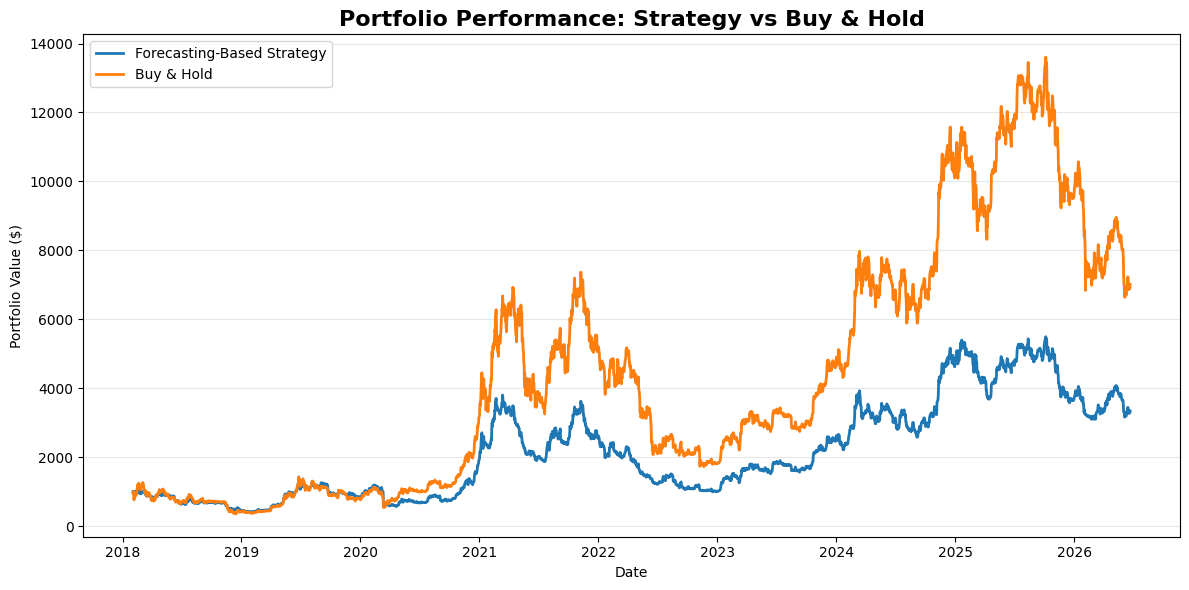

In [11]:
# ============================================
# Portfolio Performance Comparison
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    backtest_df.index,
    backtest_df["Strategy_Portfolio"],
    label="Forecasting-Based Strategy",
    linewidth=2
)

plt.plot(
    backtest_df.index,
    backtest_df["Buy_Hold_Portfolio"],
    label="Buy & Hold",
    linewidth=2
)

plt.title("Portfolio Performance: Strategy vs Buy & Hold", fontsize=16, weight="bold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# ============================================
# Portfolio Performance Summary
# ============================================

# Calculate total returns
strategy_total_return = (
    backtest_df["Strategy_Portfolio"].iloc[-1] / initial_capital - 1
) * 100

buy_hold_total_return = (
    backtest_df["Buy_Hold_Portfolio"].iloc[-1] / initial_capital - 1
) * 100


# Calculate maximum drawdown
strategy_peak = backtest_df["Strategy_Portfolio"].cummax()
buy_hold_peak = backtest_df["Buy_Hold_Portfolio"].cummax()

strategy_drawdown = (
    backtest_df["Strategy_Portfolio"] / strategy_peak - 1
) * 100

buy_hold_drawdown = (
    backtest_df["Buy_Hold_Portfolio"] / buy_hold_peak - 1
) * 100


# Create summary table
performance_summary = pd.DataFrame({
    "Metric": [
        "Initial Capital",
        "Final Portfolio Value",
        "Total Return",
        "Maximum Drawdown"
    ],
    "Forecasting-Based Strategy": [
        initial_capital,
        backtest_df["Strategy_Portfolio"].iloc[-1],
        strategy_total_return,
        strategy_drawdown.min()
    ],
    "Buy & Hold": [
        initial_capital,
        backtest_df["Buy_Hold_Portfolio"].iloc[-1],
        buy_hold_total_return,
        buy_hold_drawdown.min()
    ]
})

display(performance_summary)

,Metric,Forecasting-Based Strategy,Buy & Hold
0,Initial Capital,1000.000000,1000.000000
1,Final Portfolio Value,3339.423807,7008.745417
2,Total Return,233.942381,600.874542
3,Maximum Drawdown,-73.873351,-76.634564


#### Portfolio Comparsion Interpretation 
The portfolio comparison shows that the forecasting-based trading strategy underperformed the passive Buy & Hold benchmark over the evaluated historical period. Starting from the same hypothetical capital of $1,000, the proposed strategy reached a final portfolio value of approximately $3,339, corresponding to a total return of 233.94%, while the Buy & Hold approach reached approximately $7,009, corresponding to a total return of 600.87%.

Although the forecasting-based strategy achieved a slightly lower maximum drawdown of -73.87% compared with -76.63% for Buy & Hold, the difference was relatively small. Therefore, the reduction in downside exposure was not sufficient to compensate for the substantially lower cumulative return generated by the strategy.

These results indicate that, for the historical period evaluated, the ability to classify market regimes does not directly translate into superior investment performance. The forecasting model provides useful information about expected market conditions, but the rule-based strategy used to convert those predictions into portfolio positions would require further refinement to improve its risk-adjusted performance.

----

## Strategy Performance Evaluation

The previous section evaluated the proposed trading strategy by comparing its portfolio performance with a passive Buy & Hold benchmark. While the cumulative portfolio value provides an overall view of the strategy's performance, additional metrics are required to evaluate its profitability and risk characteristics more comprehensively.

In this section, the performance of the forecasting-based trading strategy is evaluated using quantitative performance metrics and visual analysis. The results will be used to determine how effectively the strategy balances return generation and downside risk relative to the Buy & Hold benchmark.


> ### Performance Metrics

Although the portfolio comparison provides an overall view of the strategy's performance, cumulative return alone does not fully describe the quality of an investment strategy. A strategy may generate positive returns while also experiencing substantial variability or taking excessive risk to achieve those results.

To provide a more comprehensive evaluation, several quantitative performance metrics are calculated for both the forecasting-based strategy and the Buy & Hold benchmark. These metrics allow the profitability, variability, and risk-adjusted performance of both approaches to be compared under the same historical period.

In [13]:
# ============================================
# Calculate Annualized Returns
# ============================================

# Number of years in the backtesting period
years = (
    backtest_df.index[-1] - backtest_df.index[0]
).days / 365.25

# Calculate annualized return for the strategy
strategy_annualized_return = (
    (backtest_df["Strategy_Portfolio"].iloc[-1] / initial_capital)
    ** (1 / years)
    - 1
) * 100

# Calculate annualized return for Buy & Hold
buy_hold_annualized_return = (
    (backtest_df["Buy_Hold_Portfolio"].iloc[-1] / initial_capital)
    ** (1 / years)
    - 1
) * 100

# Display results
annualized_return_summary = pd.DataFrame({
    "Metric": ["Annualized Return"],
    "Forecasting-Based Strategy": [strategy_annualized_return],
    "Buy & Hold": [buy_hold_annualized_return]
})

display(annualized_return_summary)

,Metric,Forecasting-Based Strategy,Buy & Hold
0,Annualized Return,15.46917,26.145574


The annualized return results show that the Buy & Hold benchmark generated a higher average annualized return than the forecasting-based strategy over the evaluated period. However, return alone does not account for the variability associated with generating those returns. Therefore, annualized volatility will be evaluated next to provide additional information about the risk and consistency of both approaches.

In [14]:
# ============================================
# Calculate Annualized Volatility
# ============================================

# Approximate number of trading days per year
trading_days_per_year = 252

# Calculate annualized volatility
strategy_annualized_volatility = (
    backtest_df["Strategy_Return"].std()
    * np.sqrt(trading_days_per_year)
) * 100

buy_hold_annualized_volatility = (
    backtest_df["Market_Return"].std()
    * np.sqrt(trading_days_per_year)
) * 100

# Display results
annualized_volatility_summary = pd.DataFrame({
    "Metric": ["Annualized Volatility"],
    "Forecasting-Based Strategy": [strategy_annualized_volatility],
    "Buy & Hold": [buy_hold_annualized_volatility]
})

display(annualized_volatility_summary)

,Metric,Forecasting-Based Strategy,Buy & Hold
0,Annualized Volatility,41.469824,52.400808


The annualized volatility results show that the forecasting-based strategy experienced lower return variability than the Buy & Hold benchmark over the evaluated period. The strategy recorded an annualized volatility of 41.47%, compared with 52.40% for Buy & Hold, indicating that the reduced market exposure successfully lowered fluctuations in portfolio returns. However, this reduction in volatility was accompanied by a lower annualized return. To evaluate whether the level of return generated was appropriate relative to the volatility assumed, the Sharpe Ratio is calculated next.

In [15]:
# ============================================
# Calculate Sharpe Ratio
# ============================================

# Risk-free rate assumption
risk_free_rate = 0.0

# Calculate Sharpe Ratio
strategy_sharpe_ratio = (
    (strategy_annualized_return / 100 - risk_free_rate)
    / (strategy_annualized_volatility / 100)
)

buy_hold_sharpe_ratio = (
    (buy_hold_annualized_return / 100 - risk_free_rate)
    / (buy_hold_annualized_volatility / 100)
)

# Display results
sharpe_summary = pd.DataFrame({
    "Metric": ["Sharpe Ratio"],
    "Forecasting-Based Strategy": [strategy_sharpe_ratio],
    "Buy & Hold": [buy_hold_sharpe_ratio]
})

display(sharpe_summary)

,Metric,Forecasting-Based Strategy,Buy & Hold
0,Sharpe Ratio,0.373022,0.498954


The three performance metrics provide complementary information about the behavior of both approaches. While the annualized return measures overall profitability and annualized volatility captures return variability, the Sharpe Ratio combines these aspects to evaluate risk-adjusted performance. To facilitate a direct comparison, the resulting metrics, together with the previously calculated maximum drawdown, are summarized in the following table.

In [16]:
# ============================================
# Final Performance Metrics Summary
# ============================================

performance_metrics = pd.DataFrame({
    "Metric": [
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown"
    ],
    "Forecasting-Based Strategy": [
        strategy_annualized_return,
        strategy_annualized_volatility,
        strategy_sharpe_ratio,
        strategy_drawdown.min()
    ],
    "Buy & Hold": [
        buy_hold_annualized_return,
        buy_hold_annualized_volatility,
        buy_hold_sharpe_ratio,
        buy_hold_drawdown.min()
    ]
})

display(performance_metrics)

,Metric,Forecasting-Based Strategy,Buy & Hold
0,Annualized Return,15.469170,26.145574
1,Annualized Volatility,41.469824,52.400808
2,Sharpe Ratio,0.373022,0.498954
3,Maximum Drawdown,-73.873351,-76.634564


#### Performance Metrics Interpretation 
The performance metrics indicate that the Buy & Hold benchmark outperformed the forecasting-based strategy in both absolute and risk-adjusted performance over the evaluated historical period. Buy & Hold achieved an annualized return of 26.15%, compared with 15.47% for the proposed strategy. Although the forecasting-based strategy exhibited lower annualized volatility, at 41.47% compared with 52.40% for Buy & Hold, this reduction in variability did not compensate for its lower return.

The Sharpe Ratio further supports this result, with a value of 0.373 for the forecasting-based strategy compared with 0.499 for Buy & Hold. This indicates that the passive benchmark generated a higher return relative to the volatility experienced during the evaluation period. Additionally, the maximum drawdown of the strategy (-73.87%) was only slightly lower than that of Buy & Hold (-76.63%), suggesting that the reduction in market exposure provided limited downside protection.

Overall, the forecasting-based strategy demonstrated lower return variability and a slightly lower maximum drawdown, but these advantages were not sufficient to offset its substantially lower profitability. For the historical period evaluated, Buy & Hold therefore provided the stronger overall performance and risk-adjusted return.

> ### Performance Visualization

The quantitative metrics presented in the previous subsection provide a numerical comparison of the forecasting-based strategy and the Buy & Hold benchmark. However, these metrics summarize the performance into individual values and do not show how the strategy behaved throughout the evaluation period. To complement the quantitative analysis, the portfolio performance and return behavior of both approaches are visualized to identify differences in their evolution and periods of relative performance.

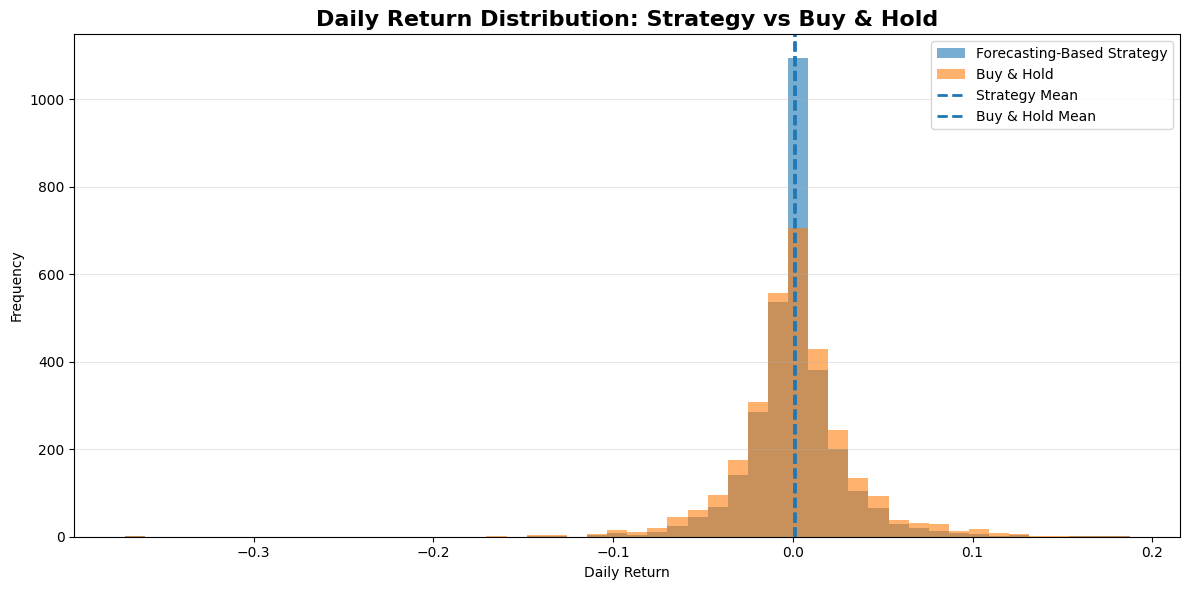

In [18]:
# ============================================
# Return Distribution Comparison
# ============================================

plt.figure(figsize=(12, 6))

plt.hist(
    backtest_df["Strategy_Return"].dropna(),
    bins=50,
    alpha=0.6,
    label="Forecasting-Based Strategy"
)

plt.hist(
    backtest_df["Market_Return"].dropna(),
    bins=50,
    alpha=0.6,
    label="Buy & Hold"
)

plt.axvline(
    backtest_df["Strategy_Return"].mean(),
    linestyle="--",
    linewidth=2,
    label="Strategy Mean"
)

plt.axvline(
    backtest_df["Market_Return"].mean(),
    linestyle="--",
    linewidth=2,
    label="Buy & Hold Mean"    
)

plt.title("Daily Return Distribution: Strategy vs Buy & Hold", fontsize=16, weight="bold")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Performance Visualization Interpretation 
The daily return distributions provide a visual representation of the differences in return variability between the forecasting-based strategy and the Buy & Hold benchmark. The forecasting-based strategy exhibits a more concentrated distribution around zero, with fewer observations in the extreme positive and negative tails. In contrast, the Buy & Hold distribution is wider and presents more pronounced tail observations, reflecting the greater variability associated with remaining continuously exposed to the market.

This visual pattern is consistent with the annualized volatility results presented in the previous subsection, where the forecasting-based strategy recorded lower volatility than Buy & Hold. However, the concentration of returns around zero also reflects the strategy's reduced market exposure and helps explain why its overall return was lower. Therefore, the visualization supports the conclusion that the proposed strategy reduced fluctuations in daily returns, but this reduction in variability came at the cost of lower profitability over the evaluated period.

> ### Strategy Evaluation Summary

The previous subsections evaluated the forecasting-based trading strategy from both quantitative and visual perspectives. The performance metrics showed how the strategy compared with Buy & Hold in terms of return, volatility, risk-adjusted performance, and maximum drawdown, while the return distribution provided additional insight into the differences in daily return variability.

This subsection brings these findings together to provide an overall assessment of the proposed strategy. The objective is to determine whether incorporating the predicted market regimes into trading decisions provided a meaningful improvement over a passive Buy & Hold approach during the historical evaluation period.